# 🧪 SST-2 Sentiment Analysis: Baseline vs Full Fine-Tuning vs LoRA PEFT


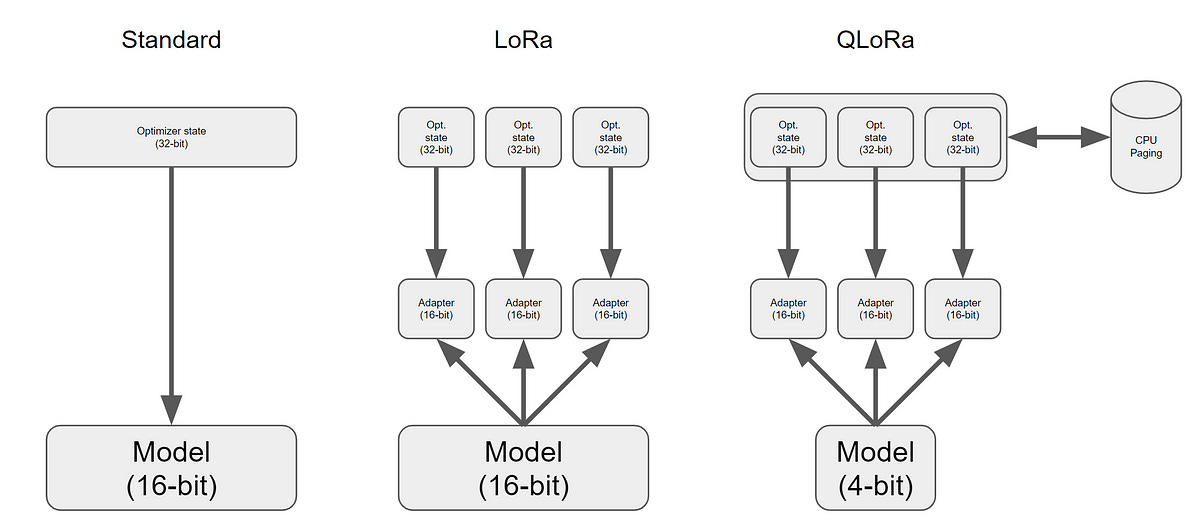

### 📌 Step 1: Install Required Libraries

In this step, we install the core libraries needed for our project:

- **transformers** → Hugging Face library for pre-trained models (BERT, GPT, LLaMA, etc.).
- **datasets** → Provides easy access to many NLP datasets.
- **peft** → Parameter-Efficient Fine-Tuning library (used for LoRA, QLoRA, etc.).
- **accelerate** → Optimizes training and inference across CPUs, GPUs, or TPUs.



### 📌 Step 2: Install Dependencies and Import Libraries

In this step, we install additional libraries and set up the environment:

- **transformers (>=4.28.0)** → Hugging Face library for working with pre-trained models.
- **datasets** → For loading and preprocessing datasets.
- **peft** → Parameter-Efficient Fine-Tuning (LoRA/QLoRA).
- **accelerate** → Makes training scalable on CPUs, GPUs, and TPUs.
- **evaluate** → Provides evaluation metrics for NLP tasks.
- **scikit-learn** → For machine learning utilities (confusion matrix, accuracy, etc.).
- **gradio** → To build simple interactive web UIs for model demos.
- **pandas** → For data handling and analysis.
- **matplotlib** → For plotting and visualization.

We also:
- Disable **Weights & Biases (wandb)** logging for simplicity.
- Disable **parallel tokenizer warnings** to reduce log noise.

Finally, we import:
- **datasets** → For dataset loading.
- **transformers classes** → Tokenizer, model, collator, training arguments, trainer.
- **peft** → To configure and apply LoRA.
- **evaluate** → For metric calculation.
- **scikit-learn** → For confusion matrix evaluation.

In [ ]:
!pip install -q "transformers>=4.28.0" "datasets" "peft" "accelerate" "evaluate" "scikit-learn" "gradio" "pandas" "torchao>=0.16.0"

import os, time, random, numpy as np, torch, pandas as pd, matplotlib.pyplot as plt
from IPython.display import display
os.environ["WANDB_DISABLED"] = "true"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

from datasets import load_dataset
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          DataCollatorWithPadding, TrainingArguments, Trainer)
from peft import LoraConfig, get_peft_model
import evaluate
from sklearn.metrics import confusion_matrix

### 📌 Step 3: Experiment Settings

Here, we configure the **global settings** for our experiment:

- **SEED = 42** → Fixes random seeds (Python, NumPy, PyTorch) to ensure reproducibility.  
- **device** → Automatically selects GPU (`cuda`) if available, otherwise CPU.  
- **USE_SUBSET** → If `True`, we train on a smaller subset of SST-2 for faster testing.  
- **EPOCHS_FULL** → Number of training epochs for full fine-tuning.  
- **EPOCHS_LORA** → Number of training epochs when using LoRA.  
- **BASE_MODEL** → Pre-trained model we will fine-tune (`distilbert-base-uncased` is a lightweight version of BERT).  

👉 This setup makes it easier to switch between **full fine-tuning** and **LoRA fine-tuning** without rewriting code.

In [ ]:
# ---------------- Settings ----------------
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

USE_SUBSET = True   # set False to train on full SST-2 (needs GPU & time)
EPOCHS_FULL = 1
EPOCHS_LORA = 1
BASE_MODEL = "distilbert-base-uncased"

Device: cuda


### 📌 Step 4: Load and Preprocess the Data

We are using the **SST-2 dataset** from the GLUE benchmark for sentiment analysis.  
This dataset contains sentences labeled as **positive** or **negative**.  

#### Steps:

1. **Load dataset**
```python
raw = load_dataset("glue", "sst2")
```
2. **Subset for faster demo (optional)**

If **USE_SUBSET=True**, we take only 5,000 training examples for a quicker run.

Validation set remains full for realistic evaluation.
3. **Tokenizer**

Use AutoTokenizer from the base model (distilbert-base-uncased).

Preprocess sentences with truncation and max length = 128.

4. **Tokenize datasets**
```python
train_tok = train_ds.map(preprocess, batched=True, remove_columns=train_ds.column_names)
valid_tok = valid_ds.map(preprocess, batched=True, remove_columns=valid_ds.column_names)

Add labels column to tokenized datasets.
```
5. **Data collator**

Handles dynamic padding during batching using **DataCollatorWithPadding**

6. **Evaluation metrics**

Compute accuracy & F1 score using the evaluate library.

The **compute_metrics** function returns both metrics for the Trainer.

7. **Utility functions**

**count_params(model)** → Counts total & trainable model parameters.

**predict_probs(model, texts)** → Returns class probabilities for given input texts.

8. **Results storage**

**results = []** → Collects training/evaluation outcomes.

In [ ]:
# ---------------- Data ----------------
# Using explicit namespace to resolve HfUriError
raw = load_dataset("nyu-mll/glue", "sst2")
if USE_SUBSET:
    train_ds = raw["train"].shuffle(SEED).select(range(5000))  # smaller for demo
    valid_ds = raw["validation"]   # full dev for realistic eval
else:
    train_ds = raw["train"]
    valid_ds = raw["validation"]

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL, use_fast=True);

def preprocess(batch):
    return tokenizer(batch["sentence"], truncation=True, max_length=128)

train_tok = train_ds.map(preprocess, batched=True, remove_columns=train_ds.column_names)
valid_tok = valid_ds.map(preprocess, batched=True, remove_columns=valid_ds.column_names)
train_tok = train_tok.add_column("labels", train_ds["label"])
valid_tok = valid_tok.add_column("labels", valid_ds["label"])
collator = DataCollatorWithPadding(tokenizer=tokenizer)

acc_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": acc_metric.compute(predictions=preds, references=labels)["accuracy"],
        "f1": f1_metric.compute(predictions=preds, references=labels, average="weighted")["f1"]
    }

def count_params(model):
    all_p = sum(p.numel() for p in model.parameters())
    train_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return int(all_p), int(train_p), 100.0*train_p/all_p

def predict_probs(model, texts):
    model.eval()
    out = []
    for t in texts:
        inputs = tokenizer(t, return_tensors="pt", truncation=True, padding=True).to(device)
        with torch.no_grad():
            logits = model(**inputs).logits
            probs = torch.softmax(logits, dim=-1).squeeze().cpu().numpy().tolist()
        out.append(probs)
    return out

# ----------------- Collect results here -----------------
results = []

Map:   0%|          | 0/872 [00:00<?, ? examples/s]

### 📌 Step 5: Baseline Evaluation (No Fine-Tuning)

- Load the **pre-trained base model** (`distilbert-base-uncased`) without any fine-tuning.
- Set up a **Trainer** for evaluation only on the validation set.
- Compute **accuracy, F1 score, and loss** using the `compute_metrics` function.
- Measure **evaluation time** and collect **model parameters**.
- Store results in `results` with `trained_params = 0` since no training is performed.


In [ ]:
# -------- Baseline (no training) -----------
print("\n=== Baseline evaluation (no fine-tuning) ===")

# Ensure results list exists even if cell 4 wasn't run recently
if 'results' not in globals():
    results = []

# Load the base model
base_eval_model = AutoModelForSequenceClassification.from_pretrained(BASE_MODEL, num_labels=2).to(device)

eval_args = TrainingArguments(output_dir="./out_eval_only", per_device_eval_batch_size=64 if device=="cuda" else 16,
                              report_to="none", logging_strategy="no")
baseline_trainer = Trainer(model=base_eval_model, args=eval_args, eval_dataset=valid_tok,
                           data_collator=collator, compute_metrics=compute_metrics)

t0 = time.time()
baseline_metrics = baseline_trainer.evaluate()
t_baseline = time.time() - t0

total_params, trainable_if_trained, trainable_pct = count_params(base_eval_model)
# Since baseline is not trained here, mark trained_params = 0
results.append({
    "model": "Baseline (no FT)",
    "eval_accuracy": baseline_metrics.get("eval_accuracy"),
    "eval_f1": baseline_metrics.get("eval_f1"),
    "eval_loss": baseline_metrics.get("eval_loss"),
    "eval_time_sec": baseline_metrics.get("eval_runtime", t_baseline),
    "total_params": total_params,
    "trained_params": 0,
    "trained_pct": 0.0,
    "train_time_min": 0.0
})
print("Baseline metrics collected and model variable initialized.\n")


=== Baseline evaluation (no fine-tuning) ===


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Training Loss,Validation Loss,Step,Accuracy,F1
No log,0.697228,0,0.434633,0.362120


Baseline metrics collected and model variable initialized.



### 📌 Step 6: Full Fine-Tuning

- Load the **pre-trained base model** for sequence classification.
- Count total and trainable parameters before training.
- Configure **TrainingArguments** for full fine-tuning:
  - Batch sizes, epochs, learning rate, weight decay, warmup, FP16, etc.
- Initialize a **Trainer** with the training and validation datasets.
- **Train the model** on the full SST-2 dataset.
- Evaluate on the validation set to compute **accuracy, F1, and loss**.
- Store training metrics, evaluation metrics, runtime, and parameter info in `results`.


In [ ]:
# -------- Full Fine-Tuning -----------
print("=== Full fine-tuning ===")
full_model = AutoModelForSequenceClassification.from_pretrained(BASE_MODEL, num_labels=2).to(device)
full_all, full_train, full_pct = count_params(full_model)
print(f"[Full] total params: {full_all:,}, (would train {full_train:,} if fully trained).")

full_args = TrainingArguments(
    output_dir="./out_full_ft",
    per_device_train_batch_size=32 if device=="cuda" else 8,
    per_device_eval_batch_size=64 if device=="cuda" else 16,
    num_train_epochs=EPOCHS_FULL,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.06,
    logging_steps=50,
    save_strategy="no",
    report_to="none",
    fp16=(device=="cuda"),
    seed=SEED,
)
full_trainer = Trainer(model=full_model, args=full_args, train_dataset=train_tok, eval_dataset=valid_tok,
                       data_collator=collator, compute_metrics=compute_metrics)

t0 = time.time()
full_trainer.train()
t_full = time.time() - t0

full_metrics = full_trainer.evaluate()
results.append({
    "model": "Full Fine-Tune",
    "eval_accuracy": full_metrics.get("eval_accuracy"),
    "eval_f1": full_metrics.get("eval_f1"),
    "eval_loss": full_metrics.get("eval_loss"),
    "eval_time_sec": full_metrics.get("eval_runtime", t_full),
    "total_params": full_all,
    "trained_params": full_train,
    "trained_pct": full_pct,
    "train_time_min": t_full/60.0
})
print("Full FT metrics collected.\n")

=== Full fine-tuning ===


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


[Full] total params: 66,955,010, (would train 66,955,010 if fully trained).


Step,Training Loss
50,0.585623
100,0.347509
150,0.330747


Training Loss,Validation Loss,Step,Accuracy,F1
0.330747,0.336844,157,0.848624,0.848406


Full FT metrics collected.



### 📌 Step 7: LoRA (PEFT) Fine-Tuning

- Load the **pre-trained base model** for sequence classification.
- Configure **LoRA adapters** with `LoraConfig`:
  - `r`, `lora_alpha`, `lora_dropout` → control adapter size and scaling.
  - `target_modules` → layers to apply LoRA.
  - `modules_to_save` → layers to keep during adapter-only fine-tuning.
- Apply adapters using `get_peft_model`.
- Count total and trainable parameters (mostly adapters + classifier head).
- Set up **TrainingArguments** for LoRA fine-tuning:
  - Higher learning rate (`2e-4`), batch sizes, epochs, warmup, FP16, etc.
- Initialize a **Trainer** with LoRA model, datasets, collator, and metrics.
- **Train the model** with adapter layers.
- Evaluate on validation set to compute **accuracy, F1, and loss**.
- Store all metrics and runtime in `results`.
- Optionally **save**:
  - Full fine-tuned model
  - LoRA adapters
  - Tokenizer


In [ ]:
# -------- LoRA (PEFT) Fine-Tuning -----------
print("=== LoRA (PEFT) fine-tuning ===")
lora_base = AutoModelForSequenceClassification.from_pretrained(BASE_MODEL, num_labels=2).to(device)
lora_cfg = LoraConfig(r=8, lora_alpha=32, lora_dropout=0.05, target_modules=["q_lin","v_lin"],
                      modules_to_save=["pre_classifier","classifier"])
lora_model = get_peft_model(lora_base, lora_cfg)

lora_all, lora_train, lora_pct = count_params(lora_model)
print(f"[LoRA] total params: {lora_all:,}, trainable (adapters+head): {lora_train:,} ({lora_pct:.4f}%)")

lora_args = TrainingArguments(
    output_dir="./out_lora",
    per_device_train_batch_size=32 if device=="cuda" else 8,
    per_device_eval_batch_size=64 if device=="cuda" else 16,
    num_train_epochs=EPOCHS_LORA,
    learning_rate=2e-4,
    weight_decay=0.01,
    warmup_ratio=0.06,
    logging_steps=50,
    save_strategy="no",
    report_to="none",
    fp16=(device=="cuda"),
    seed=SEED,
)
lora_trainer = Trainer(model=lora_model, args=lora_args, train_dataset=train_tok, eval_dataset=valid_tok,
                       data_collator=collator, compute_metrics=compute_metrics)

t0 = time.time()
lora_trainer.train()
t_lora = time.time() - t0

lora_metrics = lora_trainer.evaluate()
results.append({
    "model": "LoRA (PEFT)",
    "eval_accuracy": lora_metrics.get("eval_accuracy"),
    "eval_f1": lora_metrics.get("eval_f1"),
    "eval_loss": lora_metrics.get("eval_loss"),
    "eval_time_sec": lora_metrics.get("eval_runtime", t_lora),
    "total_params": lora_all,
    "trained_params": lora_train,
    "trained_pct": lora_pct,
    "train_time_min": t_lora/60.0
})
print("LoRA metrics collected.\n")

# Save models/adapters (optional)
full_trainer.save_model("./model_full_ft")
lora_model.save_pretrained("./model_lora_adapters")
tokenizer.save_pretrained("./model_tok")

### 📌 Step 8: Create and Display Results Table

- Convert the `results` list into a **Pandas DataFrame**.
- Reorder columns for clarity:  
  `"model", "eval_loss", "eval_accuracy", "eval_f1", "eval_time_sec", "train_time_min", "total_params", "trained_params", "trained_pct"`.
- Format values for **better readability**:
  - Accuracy, F1, and loss → 4 decimal places.
  - Evaluation time → seconds with 1 decimal place.
  - Training time → minutes with 2 decimal places.
  - Parameters → comma-separated integers.
  - Trained percentage → 4 decimal places with `%`.
- Display the **summary table** showing all models (Baseline, Full FT, LoRA) and their evaluation metrics.


In [ ]:
# ----------------- Create results table -----------------
df = pd.DataFrame(results)
# nicer column order and formatting
df = df[["model", "eval_loss", "eval_accuracy", "eval_f1", "eval_time_sec",
         "train_time_min", "total_params", "trained_params", "trained_pct"]]

# Format values for display
df_display = df.copy()
df_display["eval_accuracy"] = df_display["eval_accuracy"].apply(lambda x: f"{x:.4f}")
df_display["eval_f1"] = df_display["eval_f1"].apply(lambda x: f"{x:.4f}")
df_display["eval_loss"] = df_display["eval_loss"].apply(lambda x: f"{x:.4f}")
df_display["eval_time_sec"] = df_display["eval_time_sec"].apply(lambda x: f"{x:.1f}s")
df_display["train_time_min"] = df_display["train_time_min"].apply(lambda x: f"{x:.2f}m")
df_display["total_params"] = df_display["total_params"].apply(lambda x: f"{int(x):,}")
df_display["trained_params"] = df_display["trained_params"].apply(lambda x: f"{int(x):,}")
df_display["trained_pct"] = df_display["trained_pct"].apply(lambda x: f"{x:.4f}%")

print("=== Summary results (table) ===")
display(df_display)

### 📌 Step 9: Visualize Performance

- Grouped bar chart comparing **Accuracy** and **F1** for each model.  
- Bars annotated with numeric values for clarity.  
- X-axis: model names; Y-axis: scores (0–1).  
- Shows performance of Baseline, Full FT, and LoRA on the validation set.


In [ ]:
# -------------- Visuals --------------
# 1) Accuracy & F1 grouped bar chart (annotated)
labels = df["model"].tolist()
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8,4))
accs = df["eval_accuracy"].astype(float).values
f1s = df["eval_f1"].astype(float).values
rects1 = ax.bar(x - width/2, accs, width, label='Accuracy')
rects2 = ax.bar(x + width/2, f1s, width, label='F1 (weighted)')
ax.set_ylabel('Score'); ax.set_ylim(0,1)
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=20)
ax.set_title("Model performance (dev set)")
ax.legend()
for r in rects1 + rects2:
    h = r.get_height()
    ax.annotate(f"{h:.3f}", xy=(r.get_x() + r.get_width() / 2, h),
                xytext=(0,3), textcoords="offset points", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

### 📌 Step 10: Trainable Parameters Comparison

- Bar chart comparing **trainable parameters** for Full FT vs LoRA.  
- **Y-axis (log scale)** shows the number of trainable parameters.  
- Annotate each bar with the exact number.  
- Highlights how LoRA drastically reduces trainable parameters compared to full fine-tuning.


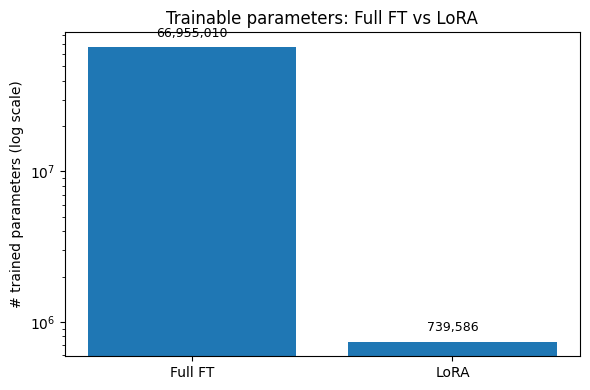

In [ ]:
# 2) Trainable params (log scale) with annotation
import matplotlib.pyplot as plt
import numpy as np

# Values
vals = [
    df.loc[df.model=="Full Fine-Tune","trained_params"].values[0],
    df.loc[df.model=="LoRA (PEFT)","trained_params"].values[0]
]

fig, ax = plt.subplots(figsize=(6,4))
ax.bar(["Full FT", "LoRA"], vals)
ax.set_yscale('log')
ax.set_ylabel('# trained parameters (log scale)')
ax.set_title("Trainable parameters: Full FT vs LoRA")

# Annotate: add a small factor in log-space
for i, v in enumerate(vals):
    ax.text(i, v * 10**0.05, f"{int(v):,}", ha='center', va='bottom', fontsize=9)
    # 10**0.05 ~ small offset in log scale

plt.tight_layout()
plt.show()



### 📌 Step 11: Training Time Comparison

- Bar chart comparing **training time (minutes)** for Full FT vs LoRA.  
- Annotate bars with exact training time values.  
- Highlights how LoRA significantly reduces training time compared to full fine-tuning.


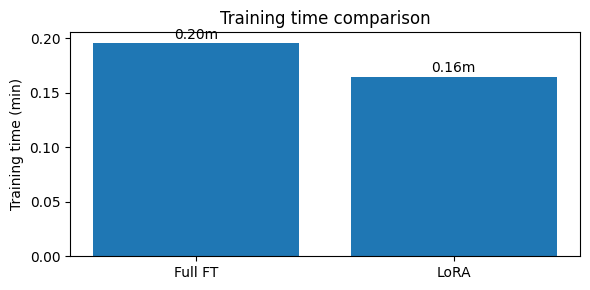

In [ ]:
# 3) Training time comparison
fig, ax = plt.subplots(figsize=(6,3))
times = [df.loc[df.model=="Full Fine-Tune","train_time_min"].values[0],
         df.loc[df.model=="LoRA (PEFT)","train_time_min"].values[0]]
ax.bar(["Full FT","LoRA"], times)
ax.set_ylabel("Training time (min)")
ax.set_title("Training time comparison")
for i, v in enumerate(times):
    ax.text(i, v + max(times)*0.02, f"{v:.2f}m", ha='center')
plt.tight_layout()
plt.show()

### 📌 Step 12: Confusion Matrices

- Display **side-by-side confusion matrices** for Full FT and LoRA models.  
- X-axis: Predicted labels; Y-axis: True labels (Negative, Positive).  
- Annotate each cell with the number of samples.  
- Provides insight into **model errors** and comparison of performance between Full Fine-Tune and LoRA.


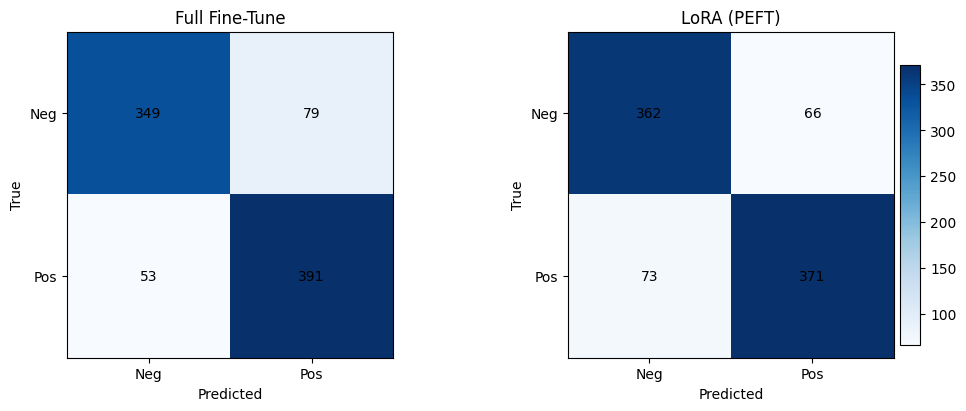

In [ ]:
# 4) Confusion matrices side-by-side (Full FT vs LoRA)
def plot_cm_for_trainer(trainer, dataset, title, ax):
    preds = trainer.predict(dataset)
    y_true = preds.label_ids
    y_pred = np.argmax(preds.predictions, axis=-1)
    cm = confusion_matrix(y_true, y_pred, labels=[0,1])
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(title)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_xticks([0,1]); ax.set_xticklabels(["Neg","Pos"])
    ax.set_yticks([0,1]); ax.set_yticklabels(["Neg","Pos"])
    for (i, j), v in np.ndenumerate(cm):
        ax.text(j, i, str(v), ha='center', va='center', color='black', fontsize=10)
    return im

fig, axs = plt.subplots(1, 2, figsize=(10,4), constrained_layout=True)

# Plot confusion matrices
im1 = plot_cm_for_trainer(full_trainer, valid_tok, "Full Fine-Tune", axs[0])
im2 = plot_cm_for_trainer(lora_trainer, valid_tok, "LoRA (PEFT)", axs[1])

# Add colorbar in a dedicated small axis on the right
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
fig.colorbar(im2, cax=cbar_ax)

plt.show()


### 📌 Step 13: Sample Predictions

- Test the models (Baseline, Full Fine-Tune, LoRA) on a few **example sentences**.  
- Compute **predicted probabilities** for positive and negative classes.  
- Display a **table** showing:
  - Baseline probabilities
  - Full FT predicted label and positive probability
  - LoRA predicted label and positive probability  
- Useful for **quick qualitative comparison** of model outputs.


In [ ]:
# ------------- Sample predictions table -------------
samples = [
    "I absolutely loved this movie, it was amazing!",
    "I hated the plot — it was terrible.",
    "Not a bad film, but not great either.",
    "One of the worst movies I've seen this year.",
    "A beautiful, moving story."
]

baseline_probs = predict_probs(base_eval_model, samples)
full_probs     = predict_probs(full_model, samples)
lora_probs     = predict_probs(lora_model, samples)

rows = []
for i, s in enumerate(samples):
    b = baseline_probs[i]
    f = full_probs[i]
    l = lora_probs[i]
    rows.append({
        "text": s,
        "baseline_neg": f"{b[0]:.3f}", "baseline_pos": f"{b[1]:.3f}",
        "full_pred": "Pos" if f[1] > f[0] else "Neg",
        "full_pos_prob": f"{f[1]:.3f}",
        "lora_pred": "Pos" if l[1] > l[0] else "Neg",
        "lora_pos_prob": f"{l[1]:.3f}"
    })
pred_df = pd.DataFrame(rows)
print("\n=== Sample predictions (Baseline / Full FT / LoRA) ===")
display(pred_df)

print("\nDone. Table + visuals displayed. You can save the DataFrame or plots for slides.")


=== Sample predictions (Baseline / Full FT / LoRA) ===


,text,baseline_neg,baseline_pos,full_pred,full_pos_prob,lora_pred,lora_pos_prob
0,"I absolutely loved this movie, it was amazing!",0.500,0.500,Pos,0.948,Pos,0.991
1,I hated the plot — it was terrible.,0.495,0.505,Neg,0.118,Neg,0.074
2,"Not a bad film, but not great either.",0.518,0.482,Neg,0.282,Neg,0.411
3,One of the worst movies I've seen this year.,0.513,0.487,Neg,0.248,Neg,0.157
4,"A beautiful, moving story.",0.513,0.487,Pos,0.966,Pos,0.996



Done. Table + visuals displayed. You can save the DataFrame or plots for slides.


### 📌 Step 14: Interactive Gradio Demo

- Build a **web interface** to compare model predictions in real time.  
- Load the three models:
  - **Baseline (no fine-tuning)**
  - **Full Fine-Tuned**
  - **LoRA PEFT**
- Map model outputs to **labels** (Negative / Positive).  
- Users can **type a sentence** and click a button to see how each model classifies it.  
- Shows **predicted label** and **confidence score** for easy comparison.


In [ ]:
import gradio as gr
from transformers import pipeline

# Load trained models
baseline_pipe = pipeline("text-classification", model=base_eval_model, tokenizer=tokenizer, device=0 if device=="cuda" else -1)
full_pipe     = pipeline("text-classification", model="./model_full_ft", tokenizer=tokenizer, device=0 if device=="cuda" else -1)
lora_pipe     = pipeline("text-classification", model="./model_lora_adapters", tokenizer="./model_tok", device=0 if device=="cuda" else -1)

# Label mapping
id2label = {0: "Negative", 1: "Positive"}

def compare_models(text):
    results = {}
    for name, pipe in [("Baseline", baseline_pipe), ("Full Fine-tuned", full_pipe), ("LoRA PEFT", lora_pipe)]:
        out = pipe(text, top_k=2)[0]
        label = id2label[int(out["label"].split("_")[-1])]
        results[name] = f"{label} ({out['score']:.2f})"
    return results["Baseline"], results["Full Fine-tuned"], results["LoRA PEFT"]

with gr.Blocks(theme="default") as demo:
    gr.Markdown("## 🔍 Compare Baseline vs Full Fine-Tuning vs LoRA PEFT")
    gr.Markdown("Type a sentence and see how different models classify it (SST-2 sentiment).")

    with gr.Row():
        inp = gr.Textbox(label="Enter a sentence", placeholder="e.g., The movie was absolutely fantastic!", lines=2)

    with gr.Row():
        out1 = gr.Label(label="Baseline (No Training)")
        out2 = gr.Label(label="Full Fine-Tuned")
        out3 = gr.Label(label="LoRA PEFT")

    btn = gr.Button("Classify with all models")
    btn.click(compare_models, inputs=inp, outputs=[out1, out2, out3])

demo.launch()


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights: 0it [00:00, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: ./model_lora_adapters
Key                                                                                                    | Status     | 
-------------------------------------------------------------------------------------------------------+------------+-
base_model.model.distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.attention.q_lin.lora_A.default.weight | UNEXPECTED | 
base_model.model.distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.attention.v_lin.lora_B.default.weight | UNEXPECTED | 
base_model.model.classifier.bias                                                                       | UNEXPECTED | 
base_model.model.distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.attention.q_lin.lora_B.default.weight | UNEXPECTED | 
base_model.model.distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.attention.v_lin.lora_A.default.weight | UNEXPECTED | 
base_model.model.classifier.weight                                          

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://937293a50577376af5.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


# 📌 QLoRA vs Full Fine-Tuning on SST-2 with Quantized OPT-125M


### 📌 Step 0: Install BitsAndBytes

- Install **bitsandbytes** library (version ≥ 0.43.0).  
- Required for **efficient 8-bit / 4-bit model quantization** and memory-efficient training.  
- Helps reduce GPU memory usage when fine-tuning large models.


In [ ]:
!pip install -U bitsandbytes


### 📌 Step 1: Install Libraries & Setup

- Install required libraries (quiet mode `-q`):  
  - `bitsandbytes` → memory-efficient model training & quantization  
  - `datasets` → load and process datasets  
  - `transformers` → Hugging Face Transformers library  
  - `peft` → Parameter-Efficient Fine-Tuning (LoRA, adapters)  
  - `accelerate` → distributed / mixed-precision training  
  - `evaluate` → compute metrics  
  - `matplotlib`, `pandas` → visualization and data handling

- Import necessary modules for:
  - Tokenization, model loading, training, evaluation
  - LoRA / PEFT setup
  - Dataset handling and plotting
- Detect device (`cuda` if GPU available, else CPU)


In [ ]:
!pip install -q bitsandbytes datasets transformers peft accelerate evaluate matplotlib pandas

import torch
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    BitsAndBytesConfig
)
from peft import LoraConfig, get_peft_model, TaskType, prepare_model_for_kbit_training
import evaluate
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from torch.utils.data import DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 MB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 9.0 MB/s eta 0:00:00
Device: cuda


### 📌 Step 2: Load Dataset & Tokenizer

- Load **SST-2** dataset from GLUE benchmark.
- Use **OPT-125M tokenizer** for tokenization.
- Preprocess:
  - Truncate & pad sentences to **max length 128**.
  - Convert dataset to PyTorch tensors.
  - Rename `"label"` column to `"labels"` for Hugging Face compatibility.
- Subset the training data to **2,000 samples** for a faster demo.
- Load **GLUE SST-2 metric** for evaluation.
- Define a utility function `compute_accuracy_from_logits` to compute **accuracy** from model outputs.


In [ ]:
# ------------------ Data & Tokenizer ------------------
# Using explicit namespace to resolve HfUriError for loading the dataset
dataset = load_dataset("nyu-mll/glue", "sst2")
tokenizer = AutoTokenizer.from_pretrained("facebook/opt-125m")

def preprocess(batch):
    return tokenizer(batch["sentence"], truncation=True, padding="max_length", max_length=128)

dataset = dataset.map(preprocess, batched=True)
dataset = dataset.rename_column("label", "labels")
dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

# Subset to keep the demo fast
train_dataset = dataset["train"].shuffle(seed=42).select(range(2000))
valid_dataset = dataset["validation"]

# Load the metric using the standard name 'glue' which evaluate expects
metric = evaluate.load("glue", "sst2")

def compute_accuracy_from_logits(all_logits, all_labels):
    preds = np.argmax(all_logits, axis=-1)
    return metric.compute(predictions=preds, references=all_labels)["accuracy"]

### 📌 Step 3: BitsAndBytes Config for Quantized Models

- Configure **memory-efficient 4-bit quantization** using `BitsAndBytesConfig`.
- Settings:
  - `load_in_4bit=True` → load model in 4-bit precision to save GPU memory.
  - `bnb_4bit_use_double_quant=True` → use double quantization for better accuracy.
  - `bnb_4bit_quant_type="nf4"` → use **NormalFloat4 (NF4)** quantization type.
  - `bnb_4bit_compute_dtype=torch.bfloat16` → perform computations in **bfloat16** for speed and stability.


In [ ]:
# ------------------ BitsAndBytes config for quantized models ------------------
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

### 📌 Step 4: Load Quantized Base Model & Manual Evaluation

- Load **OPT-125M model** in **4-bit quantized mode** using the `bnb_config`.
- Set `device_map="auto"` for automatic GPU assignment.
- Put model in **evaluation mode** (`model.eval()`).
- Define `manual_evaluate` function to:
  - Use a **DataLoader** to batch the dataset.
  - Compute **logits** for each batch without gradients.
  - Collect all labels and logits.
  - Calculate **accuracy** using `compute_accuracy_from_logits`.
  - Compute **cross-entropy loss** for reporting.
- Run manual evaluation on the validation set and print results.


In [ ]:
# ------------------ 1) Load quantized BASE model and do manual evaluation ------------------
import datasets.config
# Fix for ImportError: cannot import name 'VideoReader' from 'torchvision.io'
datasets.config.TORCHVISION_AVAILABLE = False

print("\nLoading quantized base model (4-bit) for manual eval...")
base_model = AutoModelForSequenceClassification.from_pretrained(
    "facebook/opt-125m",
    quantization_config=bnb_config,
    device_map="auto",
    num_labels=2
)
base_model.eval()

def manual_evaluate(model, dataset, batch_size=64):
    loader = DataLoader(dataset, batch_size=batch_size)
    all_logits = []
    all_labels = []
    # Note: Do NOT use model.to(device) for quantized models loaded with device_map='auto'
    with torch.no_grad():
        for batch in loader:
            # Move inputs to the same device as the model
            input_ids = batch["input_ids"].to(model.device)
            attn = batch["attention_mask"].to(model.device)
            labels = batch["labels"].numpy()

            outputs = model(input_ids=input_ids, attention_mask=attn)
            logits = outputs.logits.cpu().numpy()
            all_logits.append(logits)
            all_labels.append(labels)

    all_logits = np.vstack(all_logits)
    all_labels = np.concatenate(all_labels)
    acc = compute_accuracy_from_logits(all_logits, all_labels)

    # compute loss using torch.CrossEntropyLoss for reporting
    import torch.nn.functional as F
    logits_tensor = torch.from_numpy(all_logits)
    labels_tensor = torch.from_numpy(all_labels)
    loss = F.cross_entropy(logits_tensor, labels_tensor).item()
    return {"eval_accuracy": acc, "eval_loss": loss}

base_eval = manual_evaluate(base_model, valid_dataset, batch_size=128)
print("Base eval:", base_eval)


Loading quantized base model (4-bit) for manual eval...


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

[transformers] OPTForSequenceClassification LOAD REPORT from: facebook/opt-125m
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Base eval: {'eval_accuracy': 0.49311926605504586, 'eval_loss': 0.7685546875}


### 📌 Step 5: QLoRA (PEFT) Fine-Tuning

- Load **OPT-125M** in **4-bit quantized mode** using `bnb_config`.  
- Prepare model for **k-bit training** with `prepare_model_for_kbit_training`.  
- Apply **LoRA adapters**:
  - `r=8`, `lora_alpha=16`, `lora_dropout=0.1`
  - Task type: **Sequence Classification**
  - Bias: `"none"`
- Print **number of trainable parameters** after adding LoRA.
- Define `run_trainer_and_collect` function to:
  - Setup **Trainer** with training and evaluation datasets.
  - Train for specified **epochs** with batch size.
  - Collect **before and after evaluation metrics**, and **epoch-level logs**.
- Fine-tune **QLoRA model** on the SST-2 subset for **2 epochs**, then display evaluation metrics before and after training.


In [ ]:
# ------------------ 2) QLoRA (PEFT) fine-tuning ------------------
print("\nPreparing QLoRA model (4-bit + LoRA adapters)...")
qlora_model = AutoModelForSequenceClassification.from_pretrained(
    "facebook/opt-125m",
    quantization_config=bnb_config,
    device_map="auto",
    num_labels=2
)
qlora_model = prepare_model_for_kbit_training(qlora_model)

lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    bias="none"
)
qlora_model = get_peft_model(qlora_model, lora_config)
print("Trainable parameters (QLoRA):", sum(p.numel() for p in qlora_model.parameters() if p.requires_grad))

def run_trainer_and_collect(model, desc, train_dataset, valid_dataset, epochs=2, batch_size=8):
    args = TrainingArguments(
        output_dir=f"./{desc}_out",
        eval_strategy="epoch",
        save_strategy="no",
        learning_rate=2e-4,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=epochs,
        logging_steps=50,
        report_to="none"
    )
    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_dataset,
        eval_dataset=valid_dataset,
        compute_metrics=lambda p: {"accuracy": metric.compute(predictions=np.argmax(p[0], axis=-1), references=p[1])["accuracy"]}
    )
    before = trainer.evaluate()
    train_history = trainer.train().metrics  # returns final training metrics but trainer.state.log_history has epoch logs
    after = trainer.evaluate()
    # Collect epoch-level loss from trainer.state.log_history
    logs = trainer.state.log_history
    # extract epoch losses (training_loss) and eval losses if present
    epochs_data = []
    for entry in logs:
        if "epoch" in entry:
            epochs_data.append(entry)
    return before, after, trainer, epochs_data

before_q, after_q, trainer_q, epochs_q = run_trainer_and_collect(
    qlora_model, "qlora", train_dataset, valid_dataset, epochs=2, batch_size=8
)

print("QLoRA before eval:", before_q)
print("QLoRA after eval:", after_q)


Preparing QLoRA model (4-bit + LoRA adapters)...


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

[transformers] OPTForSequenceClassification LOAD REPORT from: facebook/opt-125m
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable parameters (QLoRA): 296448


Training Loss,Validation Loss,Epoch,Accuracy
No log,0.745471,0,0.456422


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Epoch,Training Loss,Validation Loss,Accuracy
1,0.415484,0.414144,0.823394
2,0.255412,0.339509,0.877294


Training Loss,Validation Loss,Epoch,Accuracy
0.255412,0.339509,2,0.877294


QLoRA before eval: {'eval_loss': 0.7454710602760315, 'eval_accuracy': 0.45642201834862384}
QLoRA after eval: {'eval_loss': 0.33950933814048767, 'eval_accuracy': 0.8772935779816514}


### 📌 Step 6: Full Fine-Tuning (No Quantization)

- Load **OPT-125M** in **full precision** (no 4-bit quantization).  
- Print **number of trainable parameters** for comparison with QLoRA.  
- Use the same `run_trainer_and_collect` function to:
  - Train the model on the SST-2 subset for **2 epochs**.  
  - Collect **before and after evaluation metrics** and **epoch-level logs**.  
- Allows direct comparison of **training cost** and **performance** between full fine-tuning and QLoRA.


In [ ]:
# ------------------ 3) Full fine-tuning (no quantization) ------------------
print("\nLoading full-precision model for full fine-tuning (this is larger)...")
full_model = AutoModelForSequenceClassification.from_pretrained(
    "facebook/opt-125m",
    device_map="auto",
    num_labels=2
)

print("Trainable parameters (Full):", sum(p.numel() for p in full_model.parameters() if p.requires_grad))

before_f, after_f, trainer_f, epochs_f = run_trainer_and_collect(
    full_model, "full", train_dataset, valid_dataset, epochs=2, batch_size=8
)

print("Full before eval:", before_f)
print("Full after eval:", after_f)


Loading full-precision model for full fine-tuning (this is larger)...


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

[transformers] OPTForSequenceClassification LOAD REPORT from: facebook/opt-125m
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable parameters (Full): 125240832


Training Loss,Validation Loss,Epoch,Accuracy
No log,0.771973,0,0.504587


Epoch,Training Loss,Validation Loss,Accuracy
1,0.000000,nan,0.490826
2,0.000000,nan,0.490826


Training Loss,Validation Loss,Epoch,Accuracy
0.000000,nan,2,0.490826


Full before eval: {'eval_loss': 0.77197265625, 'eval_accuracy': 0.5045871559633027}
Full after eval: {'eval_loss': nan, 'eval_accuracy': 0.4908256880733945}


### 📌 Step 7: Build Results Table

- Compare the three approaches:
  1. **Base model** (quantized, no training)  
  2. **QLoRA (PEFT)**  
  3. **Full fine-tuning** (full precision)
- Collect key metrics:
  - **Accuracy** on the validation set
  - **Loss**  
  - **Number of trainable parameters**
- Normalize metric keys across trainers using `extract_metric` to ensure consistent reporting.
- Display the **final results table** for side-by-side comparison.


In [ ]:
# ------------------ 4) Build results table ------------------
rows = [
    {"Model": "Base (quantized, no training)", "Accuracy": base_eval["eval_accuracy"], "Loss": base_eval["eval_loss"], "Trainable_params": 0},
    {"Model": "QLoRA (PEFT)", "Accuracy": after_q.get("eval_accuracy", after_q.get("eval_loss") and after_q.get("eval_accuracy", None) or None) or after_q.get("eval_accuracy", None) , "Loss": after_q.get("eval_loss", None), "Trainable_params": sum(p.numel() for p in qlora_model.parameters() if p.requires_grad)},
    {"Model": "Full fine-tune", "Accuracy": after_f.get("eval_accuracy", after_f.get("eval_accuracy", None)), "Loss": after_f.get("eval_loss", None), "Trainable_params": sum(p.numel() for p in full_model.parameters() if p.requires_grad)}
]

# Some trainers return different metric keys; normalize:
def extract_metric(d, key_candidates=("eval_accuracy","accuracy")):
    for k in key_candidates:
        if k in d:
            return d[k]
    return None

df = pd.DataFrame([
    {"Model": "Base (no training)", "Accuracy": extract_metric(base_eval, ("eval_accuracy","accuracy")), "Loss": base_eval["eval_loss"], "Trainable_params": 0},
    {"Model": "QLoRA (PEFT)", "Accuracy": extract_metric(after_q, ("eval_accuracy","accuracy")), "Loss": after_q.get("eval_loss", None), "Trainable_params": sum(p.numel() for p in qlora_model.parameters() if p.requires_grad)},
    {"Model": "Full fine-tune", "Accuracy": extract_metric(after_f, ("eval_accuracy","accuracy")), "Loss": after_f.get("eval_loss", None), "Trainable_params": sum(p.numel() for p in full_model.parameters() if p.requires_grad)}
])
print("\nResults table:")
print(df.to_string(index=False))


Results table:
             Model  Accuracy     Loss  Trainable_params
Base (no training)  0.493119 0.768555                 0
      QLoRA (PEFT)  0.877294 0.339509            296448
    Full fine-tune  0.490826      NaN         125240832


### 📌 Step 8: Plot Accuracy Comparison

- Visualize **validation accuracy** for all three models:
  - Base (quantized, no training)  
  - QLoRA (PEFT)  
  - Full fine-tuning
- Use a **bar chart** with y-axis limited to `[0,1]` for clarity.
- Rotate x-axis labels slightly for better readability.


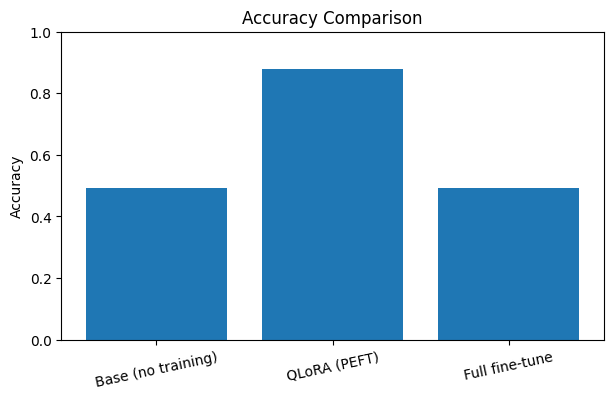

In [ ]:
# ------------------ 5) Plot accuracy comparison ------------------
plt.figure(figsize=(7,4))
plt.bar(df["Model"], df["Accuracy"])
plt.ylim(0,1)
plt.title("Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=12)
plt.show()

### 📌 Step 9: Training Loss Curves

- Extract **epoch-level training loss** from `trainer.state.log_history` for:
  - **QLoRA (PEFT)**
  - **Full fine-tuning**
- Plot **training loss per epoch** to compare convergence.
- Skip plot if no epoch-level logs are available.

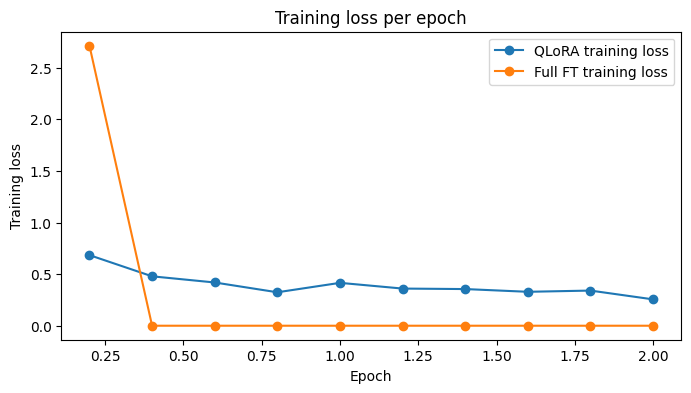

In [ ]:
# ------------------ 6) Plot training loss curves (if available) ------------------
# Extract training loss per epoch from trainer.state.log_history for QLoRA & Full
def extract_epoch_losses(logs):
    # logs is list of dict entries from trainer.state.log_history
    epoch_losses = {}
    for e in logs:
        if "epoch" in e and "loss" in e:
            epoch_losses.setdefault(e["epoch"], e["loss"])
    # return sorted by epoch
    eps = sorted(epoch_losses.items())
    if not eps:
        return [], []
    epochs, losses = zip(*eps)
    return list(epochs), list(losses)

epochs_q_nums, losses_q = extract_epoch_losses(epochs_q)
epochs_f_nums, losses_f = extract_epoch_losses(epochs_f)

plt.figure(figsize=(8,4))
if losses_q:
    plt.plot(epochs_q_nums, losses_q, marker='o', label="QLoRA training loss")
if losses_f:
    plt.plot(epochs_f_nums, losses_f, marker='o', label="Full FT training loss")
if losses_q or losses_f:
    plt.xlabel("Epoch")
    plt.ylabel("Training loss")
    plt.title("Training loss per epoch")
    plt.legend()
    plt.show()
else:
    print("\nNo epoch-level training loss entries found in trainer logs (trainer.state.log_history).")



### 📌 Step 10: Prediction Comparison

Define a small set of **test sentences**.
- Use all three models to **predict labels**:
  - Base (quantized, no training)
  - QLoRA (PEFT)
  - Full fine-tuning
- Display **predictions side-by-side** in a table to compare model behavior.

In [ ]:
# ------------------ 7) Compare predictions on same sentences ------------------
test_sentences = [
    "This movie was fantastic! I really loved it.",
    "The film was boring and too long.",
    "It was an average movie, nothing special.",
    "Absolutely terrible acting, but the story was decent."
]

def predict_labels(model, sentences, batch_size=8):
    model = model.to(device)
    model.eval()
    all_preds = []
    with torch.no_grad():
        inputs = tokenizer(sentences, return_tensors="pt", padding=True, truncation=True, max_length=128).to(device)
        outputs = model(**inputs)
        preds = torch.argmax(outputs.logits, dim=-1).cpu().numpy().tolist()
        return ["Positive" if p==1 else "Negative" for p in preds]

preds_base = predict_labels(base_model, test_sentences)
preds_qlora = predict_labels(qlora_model, test_sentences)
preds_full = predict_labels(full_model, test_sentences)

pred_df = pd.DataFrame({
    "Sentence": test_sentences,
    "Base (no training)": preds_base,
    "QLoRA": preds_qlora,
    "Full FT": preds_full
})
print("\nPrediction comparison:")
print(pred_df.to_string(index=False))


Prediction comparison:
                                             Sentence Base (no training)    QLoRA  Full FT
         This movie was fantastic! I really loved it.           Positive Positive Negative
                    The film was boring and too long.           Negative Negative Negative
            It was an average movie, nothing special.           Positive Negative Negative
Absolutely terrible acting, but the story was decent.           Positive Positive Negative
